# 6CS012 Final Portfolio Project 2026
## Image Classification with Convolutional Neural Networks
### Dataset: Intel Scene Classification (Buildings, Forest, Glacier, Mountain, Sea, Street)
---
**Name:** Atharva Paudel  
**File:** WLVID_AtharvaPaudel.ipynb

## Step 0: Mount Google Drive & Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Find the shared folder ID from the shortcut
shortcut_path = '/content/drive/MyDrive/Scene Classification'
real_path = os.path.realpath(shortcut_path)
print("Real path:", real_path)
print("Contents:", os.listdir(real_path))

Real path: /content/drive/.shortcut-targets-by-id/1CGJ0CNwG_21bChc7IMB62zHiIVsRBXOj/Scene Classification
Contents: ['train', 'test']


In [ ]:
# ─── Imports ───────────────────────────────────────────────────────────────
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
train_dir = '/content/drive/.shortcut-targets-by-id/1CGJ0CNwG_21bChc7IMB62zHiIVsRBXOj/Scene Classification/train'
test_dir  = '/content/drive/.shortcut-targets-by-id/1CGJ0CNwG_21bChc7IMB62zHiIVsRBXOj/Scene Classification/test'

CLASSES     = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = (150, 150)
BATCH_SIZE  = 32

print("Classes:", CLASSES)
print("Number of Classes:", NUM_CLASSES)

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Classes: 6


---
# PART A: Designing and Analyzing CNNs from Scratch
---

## 2.5.1 Data Understanding, Analysis, Visualization and Cleaning

In [ ]:
# ─── Count images per class ────────────────────────────────────────────────
train_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in CLASSES}
test_counts  = {cls: len(os.listdir(os.path.join(test_dir,  cls))) for cls in CLASSES}

total_train = sum(train_counts.values())
total_test  = sum(test_counts.values())

print("=== Dataset Summary ===")
print(f"Total Training Images : {total_train}")
print(f"Total Test Images     : {total_test}")
print(f"Total Images          : {total_train + total_test}")
print()
print(f"{'Class':<15} {'Train':>8} {'Test':>8}")
print("-" * 35)
for cls in CLASSES:
    print(f"{cls:<15} {train_counts[cls]:>8} {test_counts[cls]:>8}")

=== Dataset Summary ===
Total Training Images : 14034
Total Test Images     : 3000
Total Images          : 17034

Class              Train     Test
-----------------------------------
buildings           2191      437
forest              2271      474
glacier             2404      553
mountain            2512      525
sea                 2274      510
street              2382      501


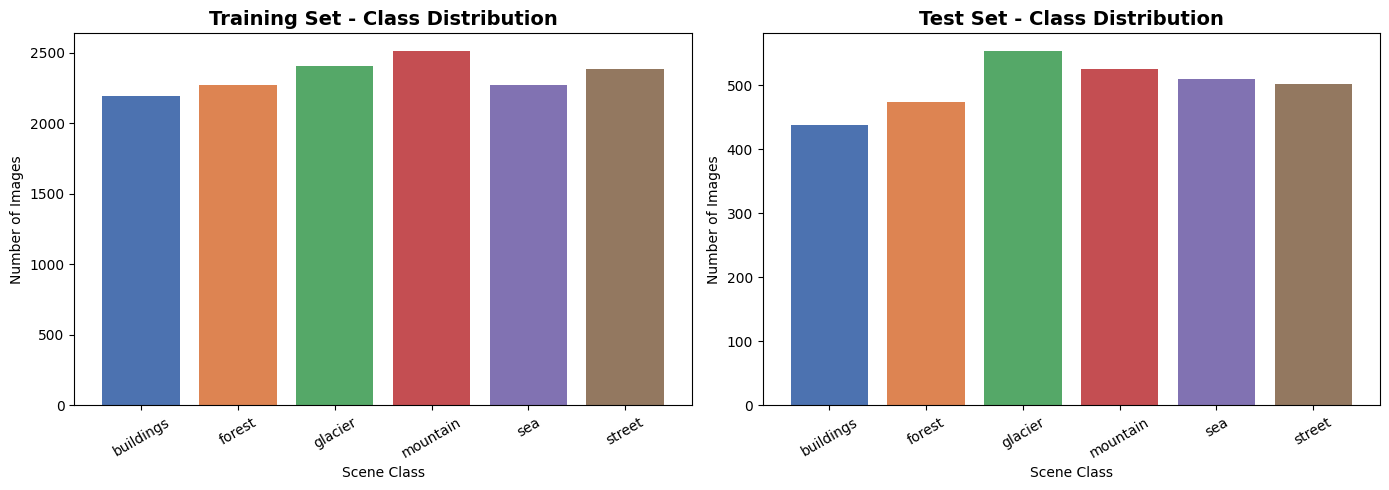

In [ ]:
# ─── Class Distribution Bar Chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

axes[0].bar(train_counts.keys(), train_counts.values(), color=colors)
axes[0].set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Scene Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(test_counts.keys(), test_counts.values(), color=colors)
axes[1].set_title('Test Set - Class Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Scene Class')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

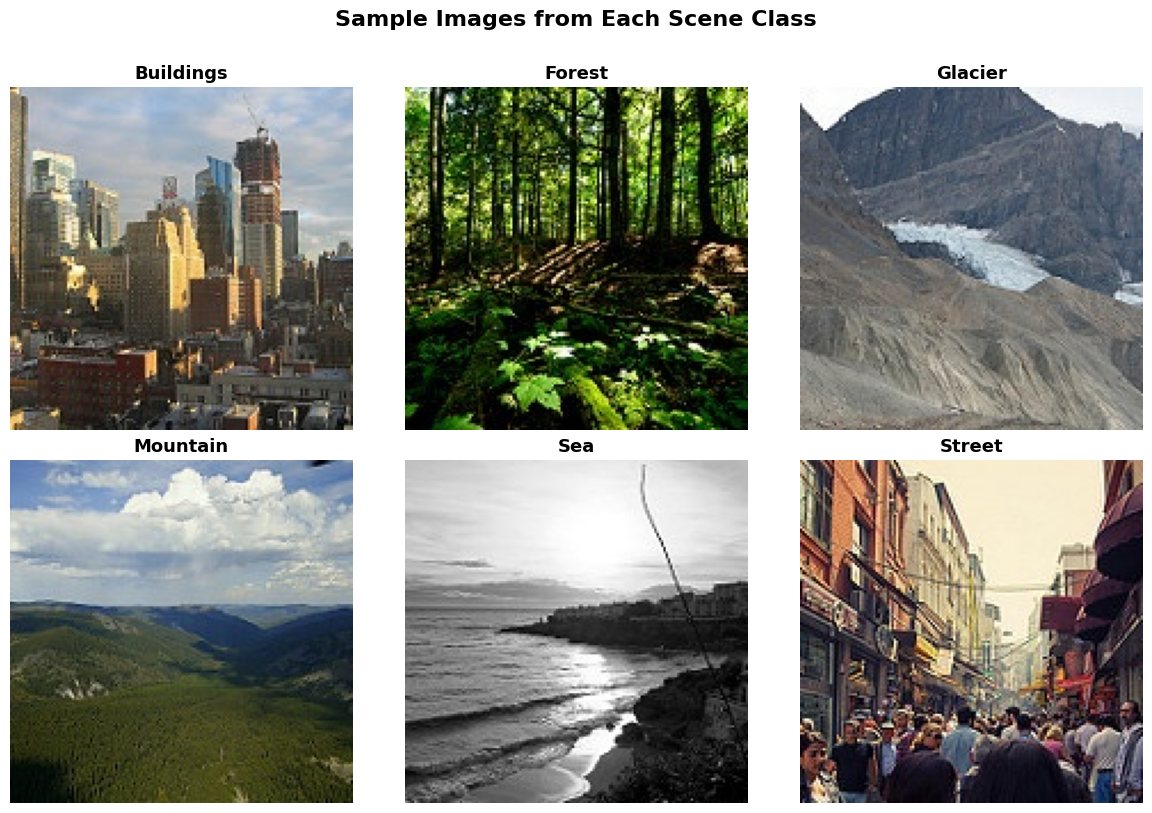

In [ ]:
# ─── Visualize Sample Images from Each Class ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(train_dir, cls)
    img_file = os.listdir(cls_path)[0]
    img = mpimg.imread(os.path.join(cls_path, img_file))
    axes[i].imshow(img)
    axes[i].set_title(cls.capitalize(), fontsize=13, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Sample Images from Each Scene Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from PIL import Image
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence

class SafeGenerator(Sequence):
    def __init__(self, directory, classes, img_size=(150,150), batch_size=32, augment=False, subset=None, validation_split=0.2, seed=42):
        self.img_size = img_size
        self.batch_size = batch_size
        self.classes = classes
        self.augment = augment
        self.class_indices = {cls: i for i, cls in enumerate(classes)}

        # Collect paths WITHOUT verifying (fast)
        all_paths, all_labels = [], []
        for cls in classes:
            cls_path = os.path.join(directory, cls)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    all_paths.append(os.path.join(cls_path, fname))
                    all_labels.append(self.class_indices[cls])

        # Train/val split
        np.random.seed(seed)
        indices = np.random.permutation(len(all_paths))
        split = int(len(indices) * validation_split)

        if subset == 'validation':
            indices = indices[:split]
        elif subset == 'training':
            indices = indices[split:]

        self.paths  = [all_paths[i]  for i in indices]
        self.labels = [all_labels[i] for i in indices]
        print(f"Found {len(self.paths)} images (subset={subset})")

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths  = self.paths[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size:(idx+1)*self.batch_size]
        images = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert('RGB').resize(self.img_size)
                img = np.array(img) / 255.0
                if self.augment and np.random.rand() > 0.5:
                    img = np.fliplr(img)
            except:
                img = np.zeros((*self.img_size, 3))  # blank image if corrupted
            images.append(img)
        X = np.array(images)
        Y = tf.keras.utils.to_categorical(batch_labels, num_classes=len(self.classes))
        return X, Y

# Create generators
print("Building generators...")
train_generator = SafeGenerator(train_dir, CLASSES, IMG_SIZE, BATCH_SIZE, augment=True,  subset='training',   validation_split=0.2)
val_generator   = SafeGenerator(train_dir, CLASSES, IMG_SIZE, BATCH_SIZE, augment=False, subset='validation', validation_split=0.2)
test_generator  = SafeGenerator(test_dir,  CLASSES, IMG_SIZE, BATCH_SIZE, augment=False, subset=None)
print("All generators ready!")

Building generators...
Found 11228 images (subset=training)
Found 2806 images (subset=validation)
Found 3000 images (subset=None)
All generators ready!


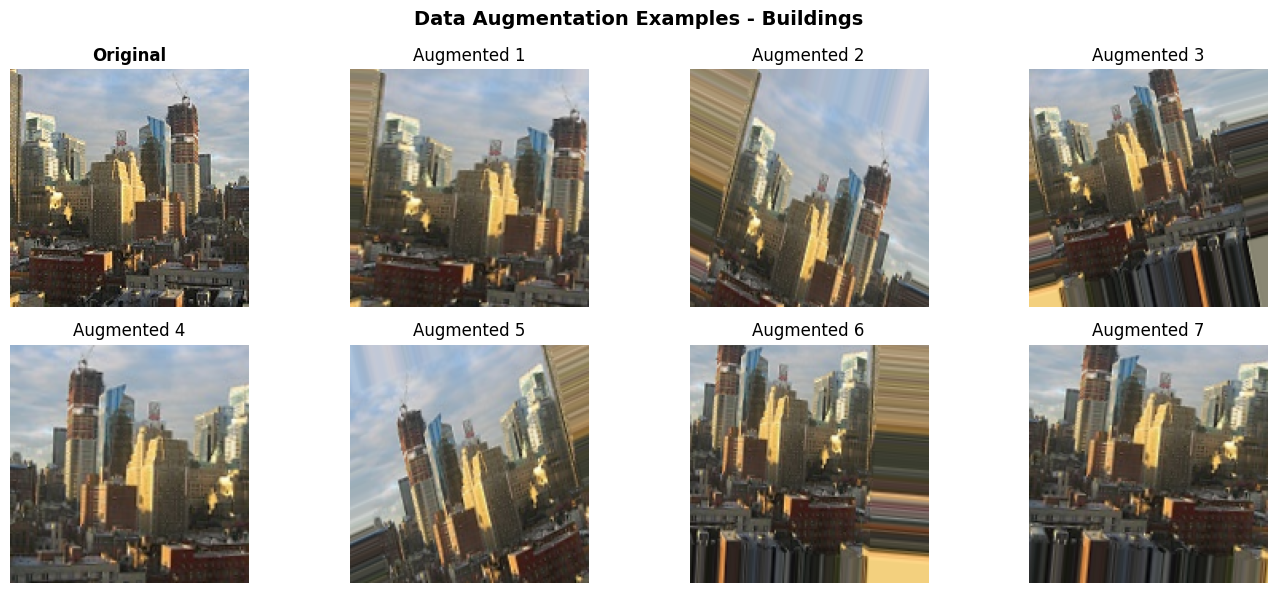

In [ ]:
# ─── Visualize Augmented Images ───────────────────────────────────────────
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Pick one sample image
sample_class = CLASSES[0]
sample_img_path = os.path.join(train_dir, sample_class, os.listdir(os.path.join(train_dir, sample_class))[0])
sample_img = mpimg.imread(sample_img_path)
sample_img = np.expand_dims(sample_img, 0)

aug_gen = aug_datagen.flow(sample_img, batch_size=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
axes[0].imshow(mpimg.imread(sample_img_path))
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 8):
    aug_img = next(aug_gen)[0]
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augmented {i}')
    axes[i].axis('off')

plt.suptitle(f'Data Augmentation Examples - {sample_class.capitalize()}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2.5.2 Baseline CNN Model

In [ ]:
# ─── Baseline Model Architecture ─────────────────────────────────────────
def build_baseline_model():
    model = models.Sequential([
        # Input
        layers.Input(shape=(150, 150, 3)),

        # Conv Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Conv Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Conv Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(2, 2),

        # Flatten
        layers.Flatten(),

        # Fully Connected Layers
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),

        # Output Layer
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ─── Train Baseline Model ─────────────────────────────────────────────────
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop],
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nBaseline Training Time: {baseline_train_time/60:.2f} minutes")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 47s 123ms/step - accuracy: 0.6044 - loss: 0.9946 - val_accuracy: 0.7384 - val_loss: 0.7534
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 115ms/step - accuracy: 0.7528 - loss: 0.6579 - val_accuracy: 0.7947 - val_loss: 0.5993
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - accuracy: 0.7993 - loss: 0.5477 - val_accuracy: 0.8033 - val_loss: 0.5693
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.8296 - loss: 0.4635 - val_accuracy: 0.8061 - val_loss: 0.5522
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.8612 - loss: 0.3812 - val_accuracy: 0.8179 - val_loss: 0.5412
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.8818 - loss: 0.3346 - val_accuracy: 0.8186 - val_loss: 0.5300
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.9082 - loss: 0.2685 - val_accuracy: 0.8336 - val_loss: 0.5362
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.9274 - loss: 0

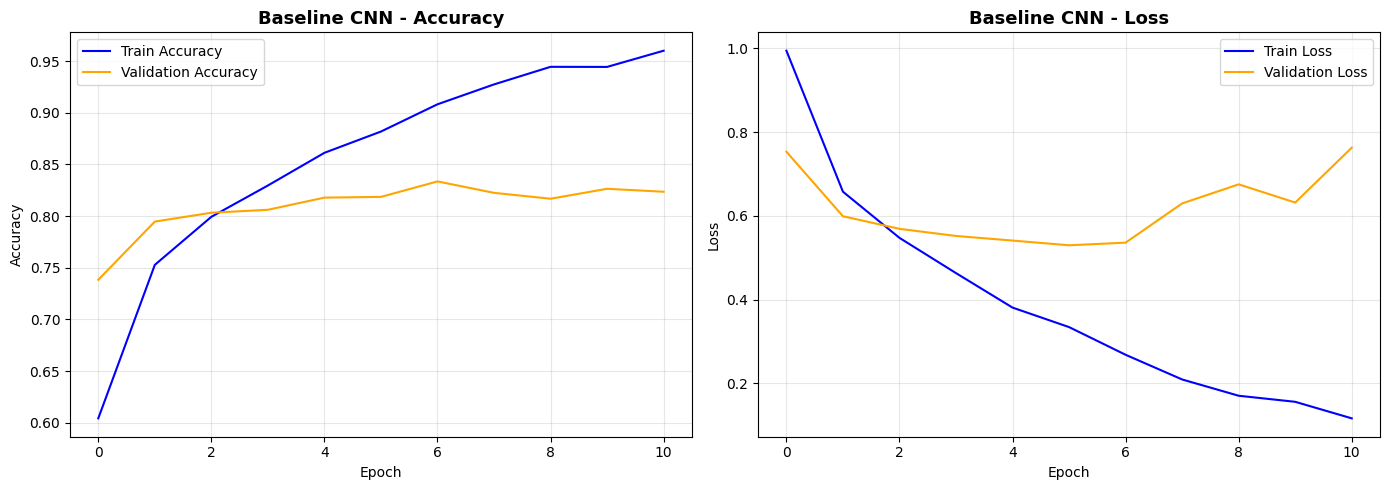

In [ ]:
# ─── Plot Training vs Validation Curves ───────────────────────────────────
def plot_history(history, title='Model'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy',  color='orange')
    axes[0].set_title(f'{title} - Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss',      color='blue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss',  color='orange')
    axes[1].set_title(f'{title} - Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, 'Baseline CNN')

94/94 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step

=== Baseline CNN - Classification Report ===
              precision    recall  f1-score   support

   buildings       0.76      0.82      0.79       437
      forest       0.95      0.95      0.95       474
     glacier       0.83      0.67      0.74       553
    mountain       0.77      0.74      0.75       525
         sea       0.72      0.84      0.78       510
      street       0.85      0.87      0.86       501

    accuracy                           0.81      3000
   macro avg       0.81      0.81      0.81      3000
weighted avg       0.81      0.81      0.81      3000



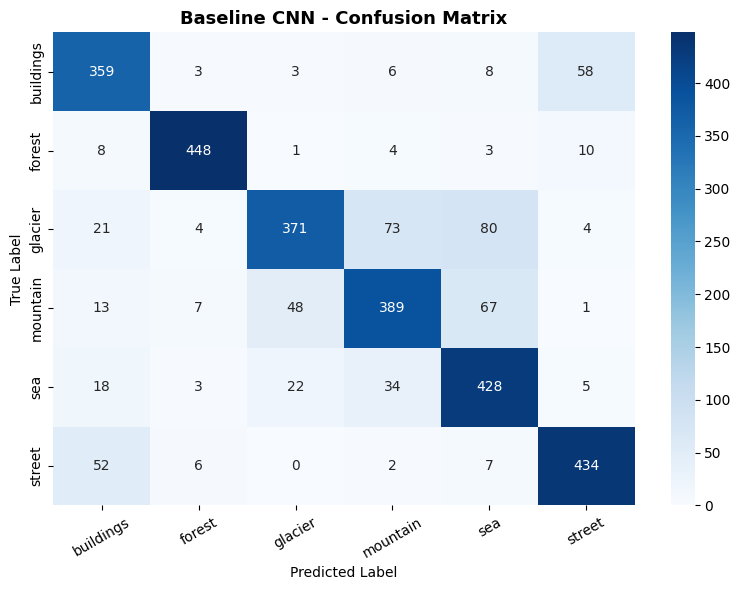

In [ ]:
def evaluate_model(model, generator, model_name='Model'):
    # Predictions
    y_pred_probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.array(generator.labels)

    # Classification Report
    print(f"\n=== {model_name} - Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_pred, y_true

baseline_preds, true_labels = evaluate_model(baseline_model, test_generator, 'Baseline CNN')

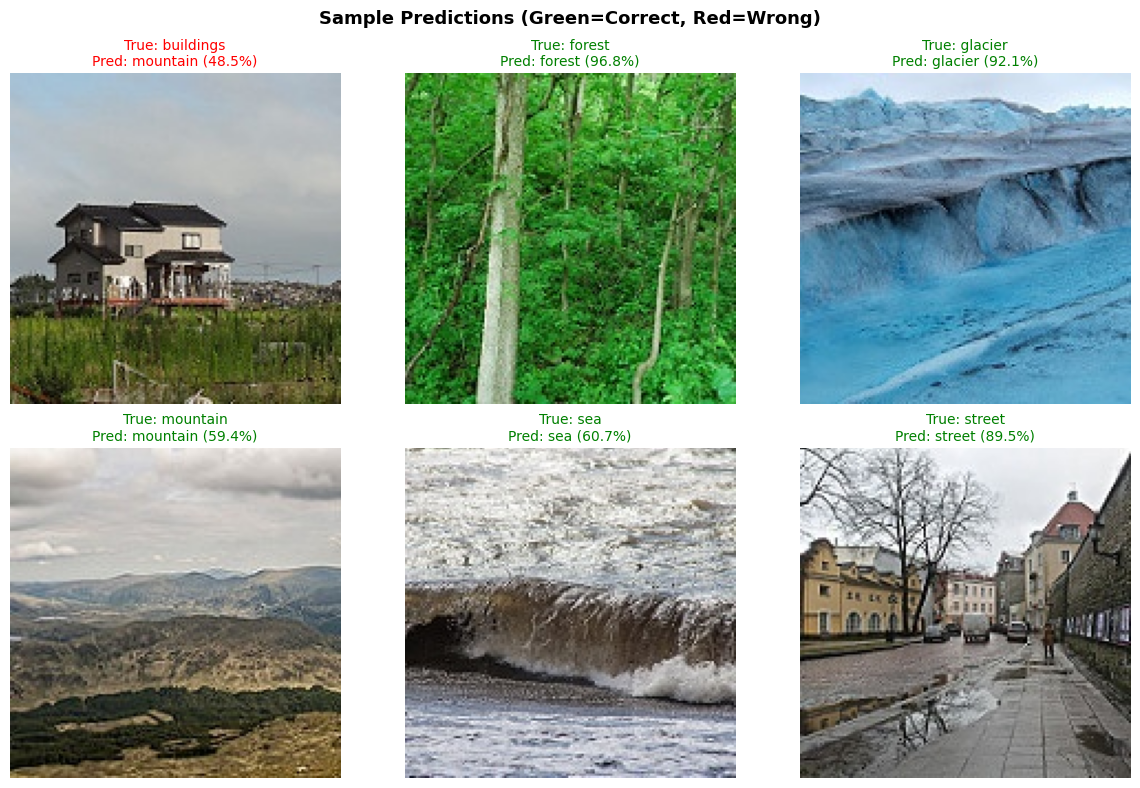

In [ ]:
# ─── Inference on Sample Images ───────────────────────────────────────────
def show_predictions(model, test_dir, classes, num_samples=6):
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for i, cls in enumerate(classes):
        cls_path = os.path.join(test_dir, cls)
        img_file = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_file)

        img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array, verbose=0)
        pred_class = classes[np.argmax(pred)]
        confidence = np.max(pred) * 100

        color = 'green' if pred_class == cls else 'red'
        axes[i].imshow(mpimg.imread(img_path))
        axes[i].set_title(f'True: {cls}\nPred: {pred_class} ({confidence:.1f}%)', color=color, fontsize=10)
        axes[i].axis('off')

    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('baseline_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, test_dir, CLASSES)

---
## 2.5.3 Deeper Architecture with Regularization

In [ ]:
# ─── Deeper CNN Model with BatchNorm + Dropout ────────────────────────────
def build_deeper_model(optimizer='adam'):
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Conv Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Conv Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Conv Block 5
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        layers.Dropout(0.25),

        # Flatten
        layers.Flatten(),

        # Fully Connected
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        # Output
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

deeper_model = build_deeper_model(optimizer='adam')
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_32 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 18, 18, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,083,046 (34.65 MB)

 Trainable params: 9,077,542 (34.63 MB)

 Non-trainable params: 5,504 (21.50 KB)

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 170ms/step - accuracy: 0.4954 - loss: 1.4000 - val_accuracy: 0.2580 - val_loss: 2.4888 - learning_rate: 0.0010
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 129ms/step - accuracy: 0.6551 - loss: 0.9139 - val_accuracy: 0.6547 - val_loss: 1.0082 - learning_rate: 0.0010
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.7447 - loss: 0.7133 - val_accuracy: 0.7192 - val_loss: 0.7932 - learning_rate: 0.0010
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 129ms/step - accuracy: 0.7738 - loss: 0.6392 - val_accuracy: 0.7327 - val_loss: 0.7777 - learning_rate: 0.0010
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.7970 - loss: 0.5869 - val_accuracy: 0.7954 - val_loss: 0.5691 - learning_rate: 0.0010
Epoch 6/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 128ms/step - accuracy: 0.8099 - loss: 0.5477 - val_accuracy: 0.8211 - val_loss: 0.5023 - learning_rate: 0.0010
Epoch 7/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.8

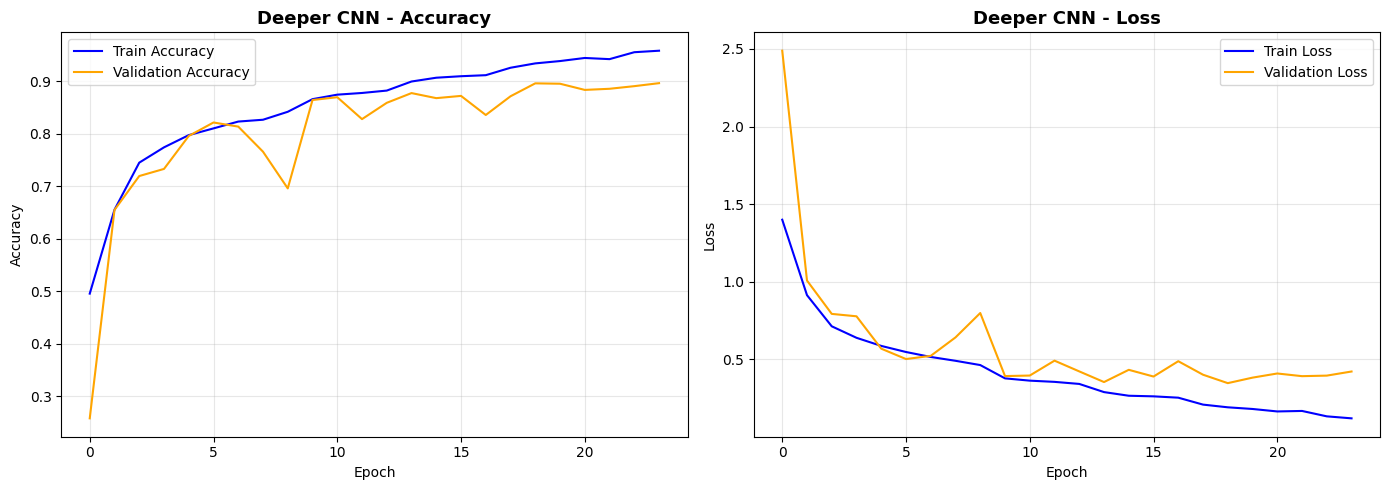

In [ ]:
# ─── Train Deeper Model ───────────────────────────────────────────────────
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

deeper_train_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_train_time/60:.2f} minutes")

plot_history(deeper_history, 'Deeper CNN')

94/94 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step

=== Deeper CNN - Classification Report ===
              precision    recall  f1-score   support

   buildings       0.87      0.91      0.89       437
      forest       0.96      0.98      0.97       474
     glacier       0.85      0.86      0.85       553
    mountain       0.85      0.85      0.85       525
         sea       0.92      0.91      0.91       510
      street       0.92      0.88      0.90       501

    accuracy                           0.90      3000
   macro avg       0.90      0.90      0.90      3000
weighted avg       0.90      0.90      0.89      3000



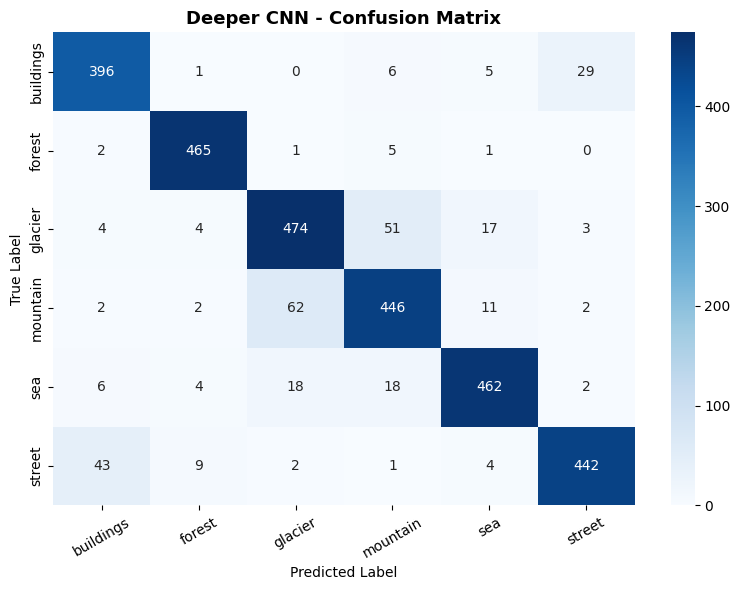

In [ ]:
# ─── Evaluate Deeper Model ────────────────────────────────────────────────
deeper_preds, _ = evaluate_model(deeper_model, test_generator, 'Deeper CNN')

---
## 2.5.4 Experimentation and Comparative Analysis

Epoch 1/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 166ms/step - accuracy: 0.4222 - loss: 1.5283 - val_accuracy: 0.4016 - val_loss: 1.5319 - learning_rate: 0.0100
Epoch 2/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 130ms/step - accuracy: 0.5448 - loss: 1.1551 - val_accuracy: 0.6044 - val_loss: 0.9939 - learning_rate: 0.0100
Epoch 3/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5912 - loss: 1.0342
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.6047 - loss: 1.0163 - val_accuracy: 0.6372 - val_loss: 0.9552 - learning_rate: 0.0100
Epoch 4/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.6712 - loss: 0.8721 - val_accuracy: 0.6939 - val_loss: 0.7762 - learning_rate: 0.0050
Epoch 5/25
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.6955 - loss: 0.8087 - val_accuracy: 0.6939 - val_loss: 0.8128 - learning_rate: 0.0050

SGD Training Time: 4.24 minutes


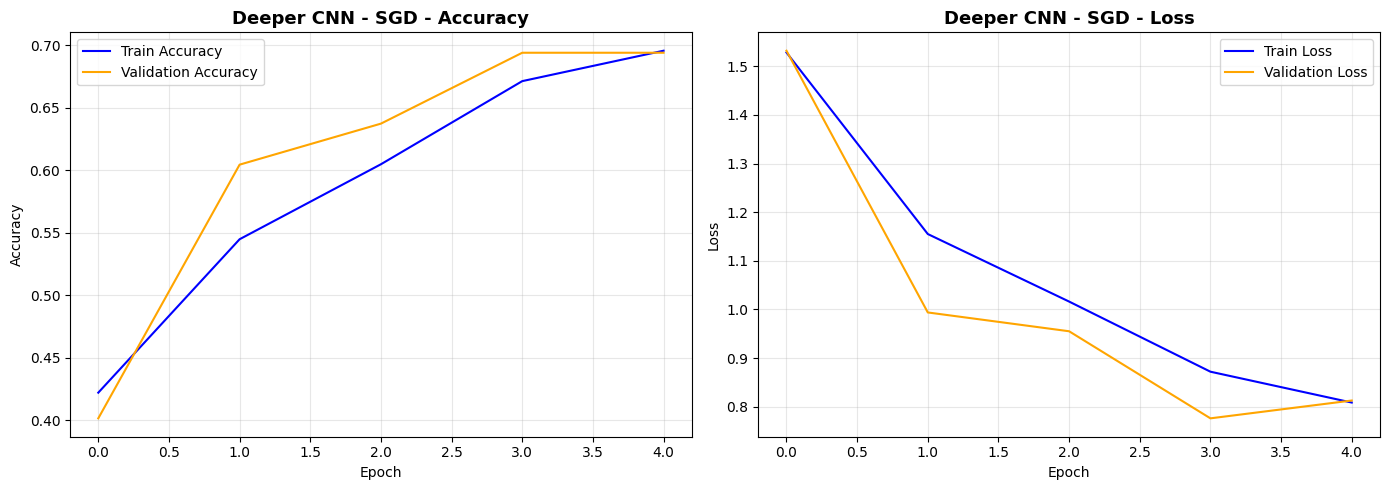

In [ ]:
# ─── Optimizer Comparison: SGD ────────────────────────────────────────────
sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
deeper_model_sgd = build_deeper_model(optimizer=sgd_optimizer)

start_time = time.time()

sgd_history = deeper_model_sgd.fit(
    train_generator,
    epochs=25,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

sgd_train_time = time.time() - start_time
print(f"\nSGD Training Time: {sgd_train_time/60:.2f} minutes")

plot_history(sgd_history, 'Deeper CNN - SGD')

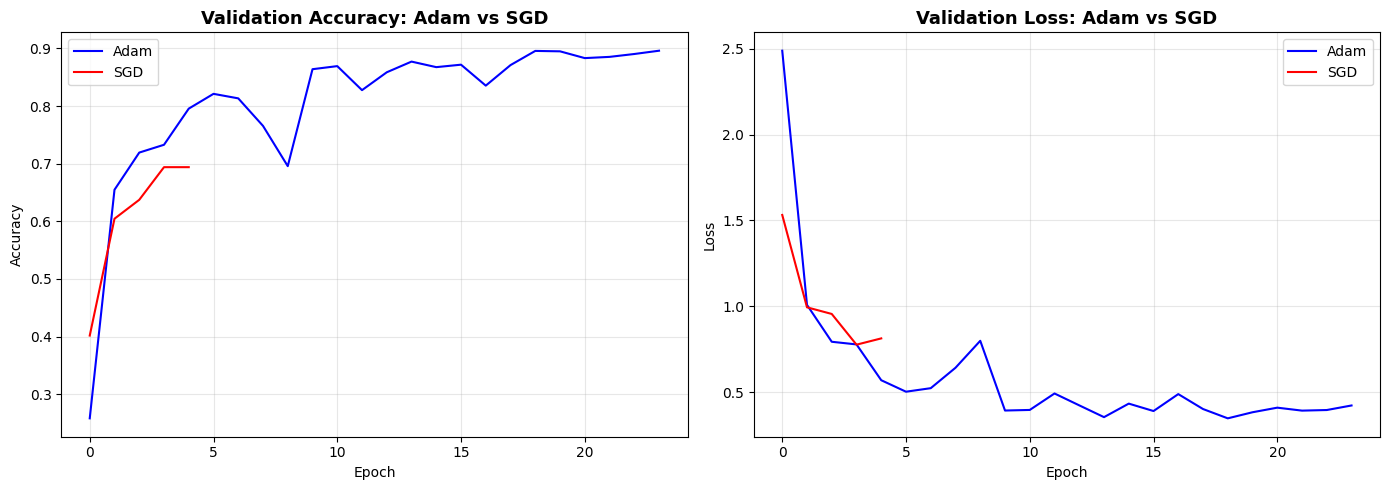

In [ ]:
# ─── SGD vs Adam Comparison Plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Accuracy
axes[0].plot(deeper_history.history['val_accuracy'], label='Adam',  color='blue')
axes[0].plot(sgd_history.history['val_accuracy'],    label='SGD',   color='red')
axes[0].set_title('Validation Accuracy: Adam vs SGD', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(deeper_history.history['val_loss'], label='Adam', color='blue')
axes[1].plot(sgd_history.history['val_loss'],    label='SGD',  color='red')
axes[1].set_title('Validation Loss: Adam vs SGD', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 57s 137ms/step - accuracy: 0.5554 - loss: 2.8578 - val_accuracy: 0.2398 - val_loss: 2.2061
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 118ms/step - accuracy: 0.7283 - loss: 0.7658 - val_accuracy: 0.6080 - val_loss: 1.0115
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 121ms/step - accuracy: 0.7971 - loss: 0.5556 - val_accuracy: 0.7880 - val_loss: 0.5979
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 118ms/step - accuracy: 0.8342 - loss: 0.4663 - val_accuracy: 0.7773 - val_loss: 0.6820
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 120ms/step - accuracy: 0.8418 - loss: 0.4362 - val_accuracy: 0.8090 - val_loss: 0.5256
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 119ms/step - accuracy: 0.8567 - loss: 0.3909 - val_accuracy: 0.8133 - val_loss: 0.5806
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 42s 121ms/step - accuracy: 0.8661 - loss: 0.3601 - val_accuracy: 0.6297 - val_loss: 1.4203
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 45s 127ms/step - accuracy: 0.8758 - loss: 0

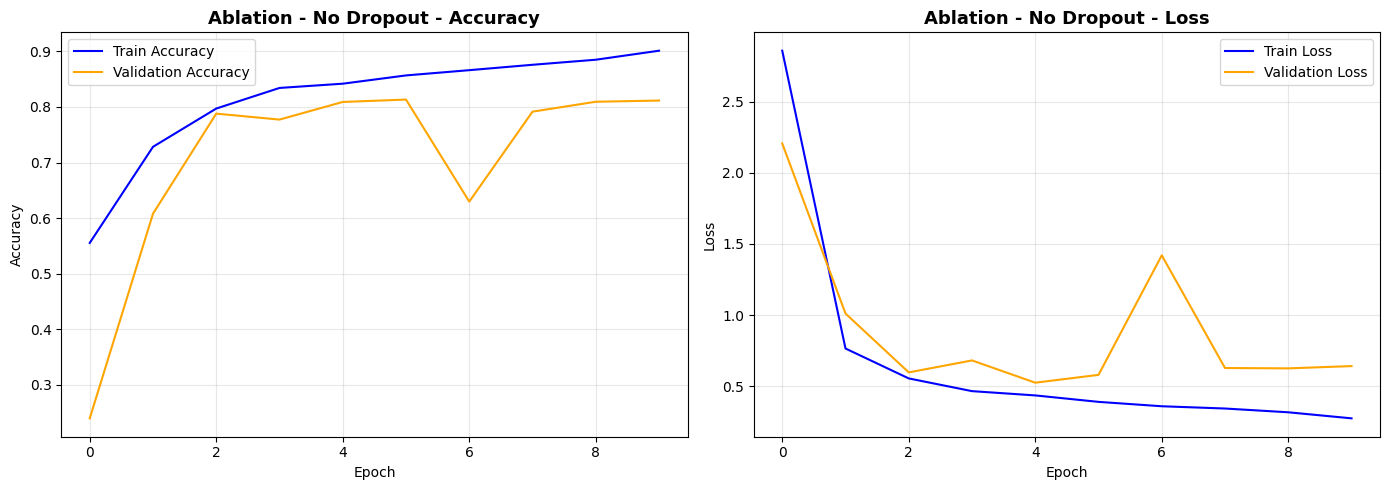

In [ ]:
# ─── Ablation Study: Remove Dropout ──────────────────────────────────────
def build_no_dropout_model():
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='No_Dropout_CNN')

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

ablation_model = build_no_dropout_model()

ablation_history = ablation_model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

plot_history(ablation_history, 'Ablation - No Dropout')

In [ ]:
# ─── Summary Comparison Table ─────────────────────────────────────────────
baseline_loss, baseline_acc = baseline_model.evaluate(test_generator, verbose=0)
deeper_loss,   deeper_acc   = deeper_model.evaluate(test_generator, verbose=0)
sgd_loss,      sgd_acc      = deeper_model_sgd.evaluate(test_generator, verbose=0)
ablation_loss, ablation_acc = ablation_model.evaluate(test_generator, verbose=0)

print("\n" + "="*65)
print(f"{'Model':<30} {'Test Accuracy':>14} {'Test Loss':>10} {'Train Time':>10}")
print("="*65)
print(f"{'Baseline CNN (Adam)':<30} {baseline_acc*100:>13.2f}% {baseline_loss:>10.4f} {baseline_train_time/60:>8.1f}m")
print(f"{'Deeper CNN (Adam)':<30} {deeper_acc*100:>13.2f}% {deeper_loss:>10.4f} {deeper_train_time/60:>8.1f}m")
print(f"{'Deeper CNN (SGD)':<30} {sgd_acc*100:>13.2f}% {sgd_loss:>10.4f} {sgd_train_time/60:>8.1f}m")
print(f"{'Deeper CNN (No Dropout)':<30} {ablation_acc*100:>13.2f}% {ablation_loss:>10.4f} {'N/A':>10}")
print("="*65)


Model                           Test Accuracy  Test Loss Train Time
Baseline CNN (Adam)                    80.97%     0.5408      7.6m
Deeper CNN (Adam)                      89.50%     0.3308     19.5m
Deeper CNN (SGD)                       38.43%     1.5337      4.2m
Deeper CNN (No Dropout)                82.47%     0.5045        N/A


---
# PART B: Fine-Tuning a Pre-Trained Model (Transfer Learning)
---

In [ ]:
# ─── Data Generators for Transfer Learning (224x224) ─────────────────────
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)

tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

tl_val_gen = tl_train_datagen.flow_from_directory(
    train_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

tl_test_gen = tl_test_datagen.flow_from_directory(
    test_dir,
    target_size=TL_IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [ ]:
# ─── Load MobileNetV2 Pre-Trained Model ───────────────────────────────────
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,        # Remove original 1000-class output layer
    input_shape=(224, 224, 3)
)

# Freeze the convolutional base (Feature Extraction)
base_model.trainable = False

# Build the full model
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')

transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,590 (9.99 MB)

 Trainable params: 361,606 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# ─── Data Generators for Transfer Learning (224x224) ─────────────────────
TL_IMG_SIZE = (224, 224)

print("Building transfer learning generators...")

tl_train_gen = SafeGenerator(
    train_dir, CLASSES, TL_IMG_SIZE, BATCH_SIZE,
    augment=True, subset='training', validation_split=0.2
)

tl_val_gen = SafeGenerator(
    train_dir, CLASSES, TL_IMG_SIZE, BATCH_SIZE,
    augment=False, subset='validation', validation_split=0.2
)

tl_test_gen = SafeGenerator(
    test_dir, CLASSES, TL_IMG_SIZE, BATCH_SIZE,
    augment=False, subset=None
)

print("Transfer learning generators ready!")

Building transfer learning generators...
Found 11228 images (subset=training)
Found 2806 images (subset=validation)
Found 3000 images (subset=None)
Transfer learning generators ready!


Phase 2: Fine-tuning (unfreezing top layers)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 141s 323ms/step - accuracy: 0.4536 - loss: 1.3932 - val_accuracy: 0.8086 - val_loss: 0.6890 - learning_rate: 1.0000e-05
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.7538 - loss: 0.6956 - val_accuracy: 0.8564 - val_loss: 0.3961 - learning_rate: 1.0000e-05
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 225ms/step - accuracy: 0.8280 - loss: 0.4905 - val_accuracy: 0.8731 - val_loss: 0.3353 - learning_rate: 1.0000e-05
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 78s 221ms/step - accuracy: 0.8624 - loss: 0.4071 - val_accuracy: 0.8874 - val_loss: 0.2953 - learning_rate: 1.0000e-05
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 77s 218ms/step - accuracy: 0.8797 - loss: 0.3522 - val_accuracy: 0.8974 - val_loss: 0.2773 - learning_rate: 1.0000e-05
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 214ms/step - accuracy: 0.8897 - loss: 0.3215 - val_accuracy: 0.9052 - val_loss: 0.2599 - learning_rate: 1.0000e-05
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 79s 2

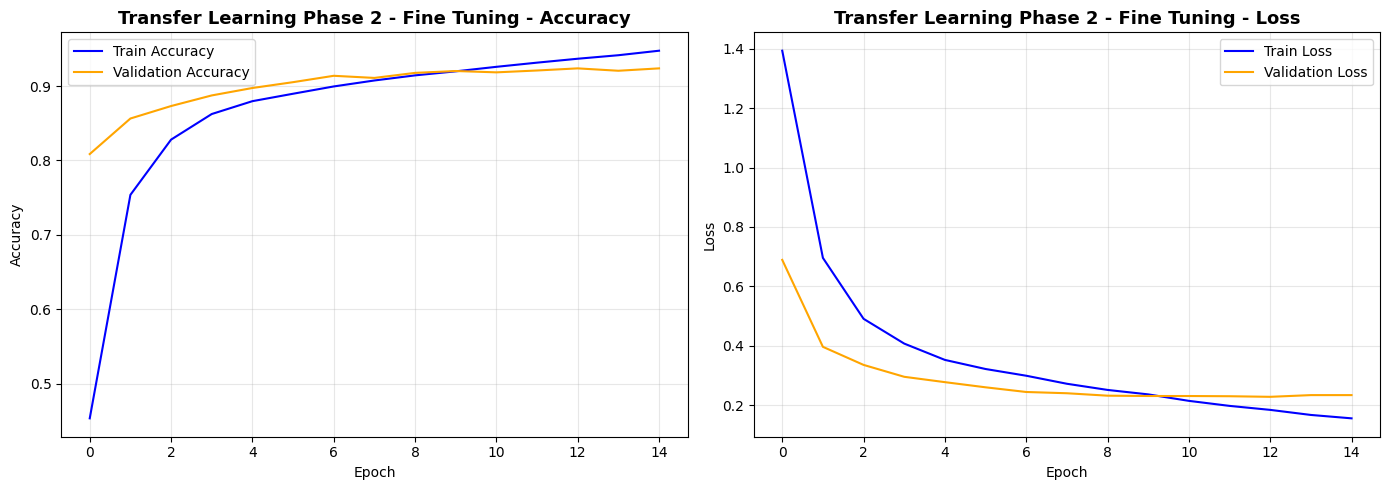

In [ ]:
# ─── Phase 2: Fine-Tuning (Unfreeze top layers) ───────────────────────────
print("Phase 2: Fine-tuning (unfreezing top layers)...")

# Unfreeze the top 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a lower learning rate
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_time = time.time()

phase2_history = transfer_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
    ],
    verbose=1
)

phase2_time = time.time() - start_time
print(f"Phase 2 Training Time: {phase2_time/60:.2f} minutes")

plot_history(phase2_history, 'Transfer Learning Phase 2 - Fine Tuning')

94/94 ━━━━━━━━━━━━━━━━━━━━ 36s 305ms/step

=== MobileNetV2 Transfer Learning - Classification Report ===
              precision    recall  f1-score   support

   buildings       0.93      0.94      0.93       437
      forest       0.98      0.99      0.99       474
     glacier       0.91      0.83      0.87       553
    mountain       0.85      0.88      0.87       525
         sea       0.94      0.98      0.96       510
      street       0.94      0.94      0.94       501

    accuracy                           0.92      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.92      0.92      0.92      3000



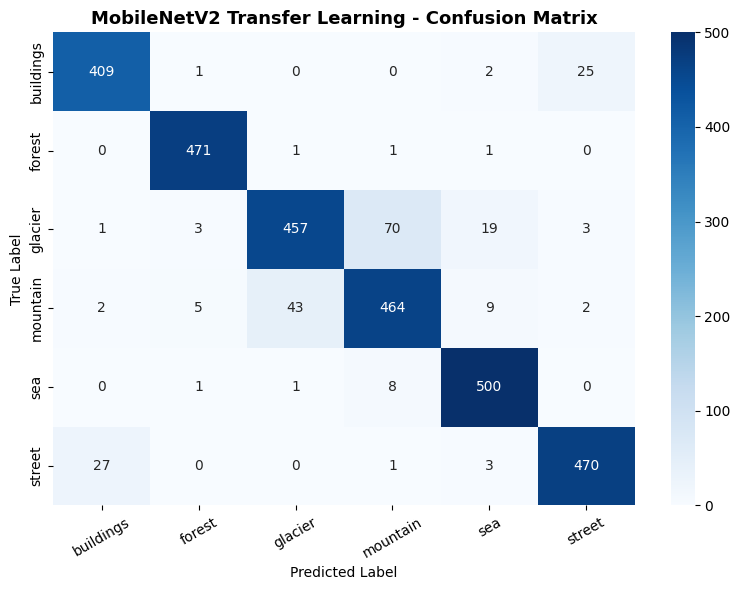

In [ ]:
# ─── Evaluate Transfer Learning Model ────────────────────────────────────
tl_preds, _ = evaluate_model(transfer_model, tl_test_gen, 'MobileNetV2 Transfer Learning')

In [ ]:
# ─── Final Comparison: All Models ─────────────────────────────────────────
tl_loss, tl_acc = transfer_model.evaluate(tl_test_gen, verbose=0)

print("\n" + "="*65)
print("FINAL MODEL COMPARISON")
print("="*65)
print(f"{'Model':<35} {'Test Accuracy':>14} {'Test Loss':>10}")
print("-"*65)
print(f"{'Baseline CNN (Adam)':<35} {baseline_acc*100:>13.2f}% {baseline_loss:>10.4f}")
print(f"{'Deeper CNN (Adam)':<35} {deeper_acc*100:>13.2f}% {deeper_loss:>10.4f}")
print(f"{'Deeper CNN (SGD)':<35} {sgd_acc*100:>13.2f}% {sgd_loss:>10.4f}")
print(f"{'Deeper CNN (No Dropout - Ablation)':<35} {ablation_acc*100:>13.2f}% {ablation_loss:>10.4f}")
print(f"{'MobileNetV2 Transfer Learning':<35} {tl_acc*100:>13.2f}% {tl_loss:>10.4f}")
print("="*65)


FINAL MODEL COMPARISON
Model                                Test Accuracy  Test Loss
-----------------------------------------------------------------
Baseline CNN (Adam)                         80.97%     0.5408
Deeper CNN (Adam)                           89.50%     0.3308
Deeper CNN (SGD)                            38.43%     1.5337
Deeper CNN (No Dropout - Ablation)          82.47%     0.5045
MobileNetV2 Transfer Learning               92.37%     0.2219


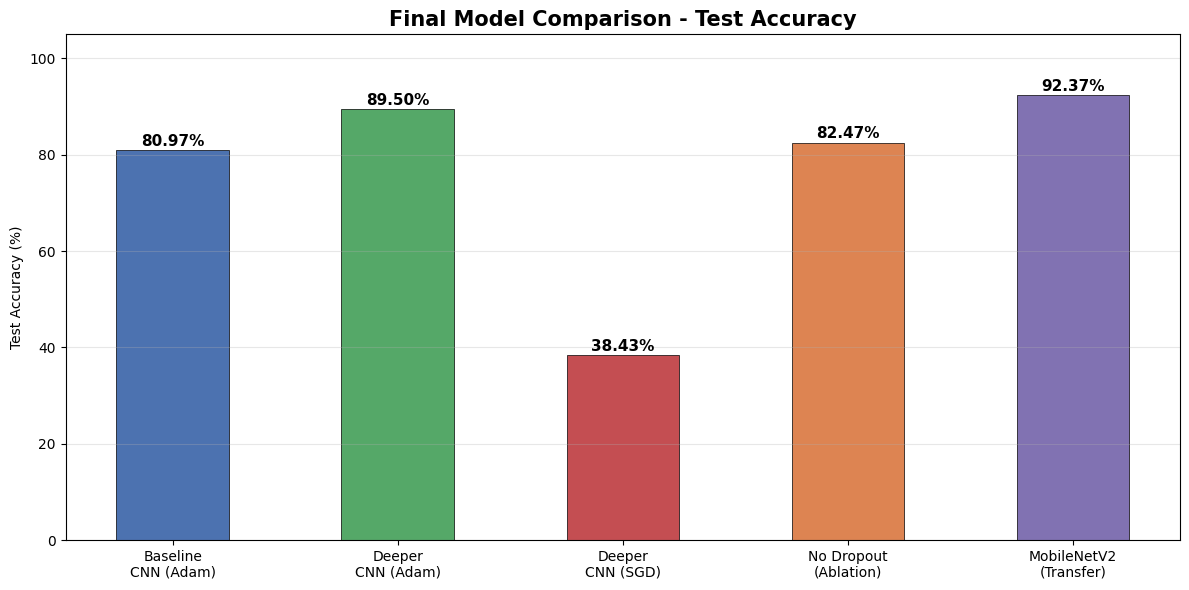

In [ ]:
# ─── Bar Chart: Final Model Comparison ───────────────────────────────────
model_names = [
    'Baseline\nCNN (Adam)',
    'Deeper\nCNN (Adam)',
    'Deeper\nCNN (SGD)',
    'No Dropout\n(Ablation)',
    'MobileNetV2\n(Transfer)'
]
accuracies = [
    baseline_acc*100,
    deeper_acc*100,
    sgd_acc*100,
    ablation_acc*100,
    tl_acc*100
]

colors = ['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2']

plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, accuracies, color=colors, width=0.5, edgecolor='black', linewidth=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.title('Final Model Comparison - Test Accuracy', fontsize=15, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()